In [21]:
# Import libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
penguins = pd.read_csv('data/palmer_penguins.csv')

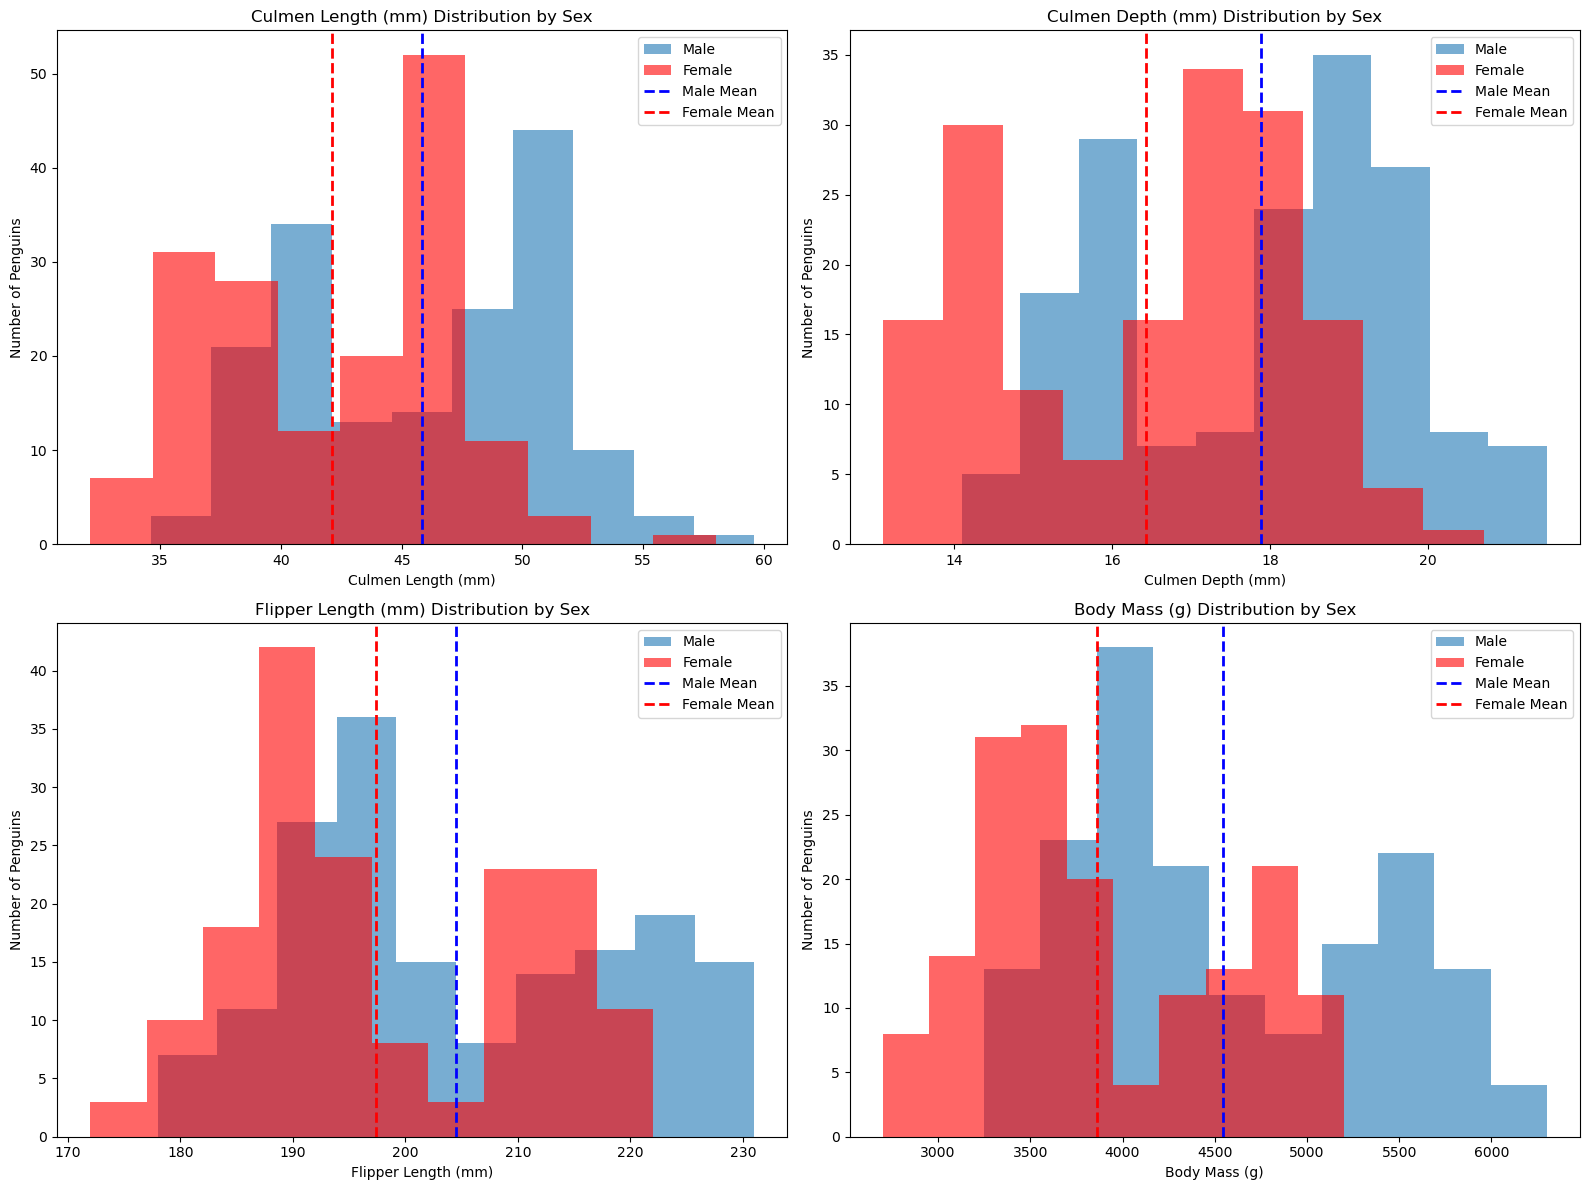

In [22]:
# Visualize how penguin sex relates to numerical variables

male_penguins = penguins[penguins['Sex'] == 'MALE'] 
female_penguins = penguins[penguins['Sex'] == 'FEMALE']

columns = [
    'Culmen Length (mm)', 
    'Culmen Depth (mm)', 
    'Flipper Length (mm)', 
    'Body Mass (g)'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)

    plt.hist(male_penguins[col], label='Male', alpha=0.6)
    plt.hist(female_penguins[col], label='Female', color='red', alpha=0.6)

    plt.axvline(male_penguins[col].mean(), color='blue', linestyle='--', linewidth=2, label='Male Mean')
    plt.axvline(female_penguins[col].mean(), color='red', linestyle='--', linewidth=2, label='Female Mean')

    plt.xlabel(col)
    plt.ylabel("Number of Penguins")
    plt.title(col + ' Distribution by Sex')
    plt.legend()

plt.tight_layout()
plt.show()

In [23]:
columns = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

# Compute statistics for Male
male_stats = pd.DataFrame({'Mean': male_penguins[columns].mean(),'Std': male_penguins[columns].std(),'Median': male_penguins[columns].median(),'Min': male_penguins[columns].min(),'Max': male_penguins[columns].max(),'IQR': male_penguins[columns].quantile(0.75) - male_penguins[columns].quantile(0.25)})

# Compute statistics for Female
female_stats = pd.DataFrame({'Mean': female_penguins[columns].mean(),'Std': female_penguins[columns].std(),'Median': female_penguins[columns].median(),'Min': female_penguins[columns].min(),'Max': female_penguins[columns].max(),'IQR': female_penguins[columns].quantile(0.75) - female_penguins[columns].quantile(0.25)})


summary_table = pd.concat([male_stats, female_stats], axis=1, keys=['Male', 'Female'])
summary_table

Male                                       \
                            Mean         Std   Median     Min     Max   
Culmen Length (mm)     45.854762    5.366896    46.80    34.6    59.6   
Culmen Depth (mm)      17.891071    1.863351    18.45    14.1    21.5   
Flipper Length (mm)   204.505952   14.547876   200.50   178.0   231.0   
Body Mass (g)        4545.684524  787.628884  4300.00  3250.0  6300.0   

                                    Female                              \
                          IQR         Mean         Std  Median     Min   
Culmen Length (mm)      9.350    42.096970    4.903476    42.8    32.1   
Culmen Depth (mm)       3.175    16.425455    1.795681    17.0    13.1   
Flipper Length (mm)    26.000   197.363636   12.500776   193.0   172.0   
Body Mass (g)        1412.500  3862.272727  666.172050  3650.0  2700.0   

                                     
                        Max     IQR  
Culmen Length (mm)     58.0     8.6  
Culmen Depth (mm)      20.7     3.3  
Flipper Length (mm)   222.0    23.0  
Body Mass (g)        5200.0  1200.0

In [24]:
# Calculate the average physical measurements for each penguin species

species = penguins.groupby('Species').mean(numeric_only=True)
species

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
Species,,,,,,,
Adelie Penguin (Pygoscelis adeliae),76.5,38.791391,18.346358,189.953642,3700.662252,8.859733,-25.804194
Chinstrap penguin (Pygoscelis antarctica),34.5,48.833824,18.420588,195.823529,3733.088235,9.356155,-24.546542
Gentoo penguin (Pygoscelis papua),62.5,47.504878,14.982114,217.186992,5076.016260,8.245338,-26.185298


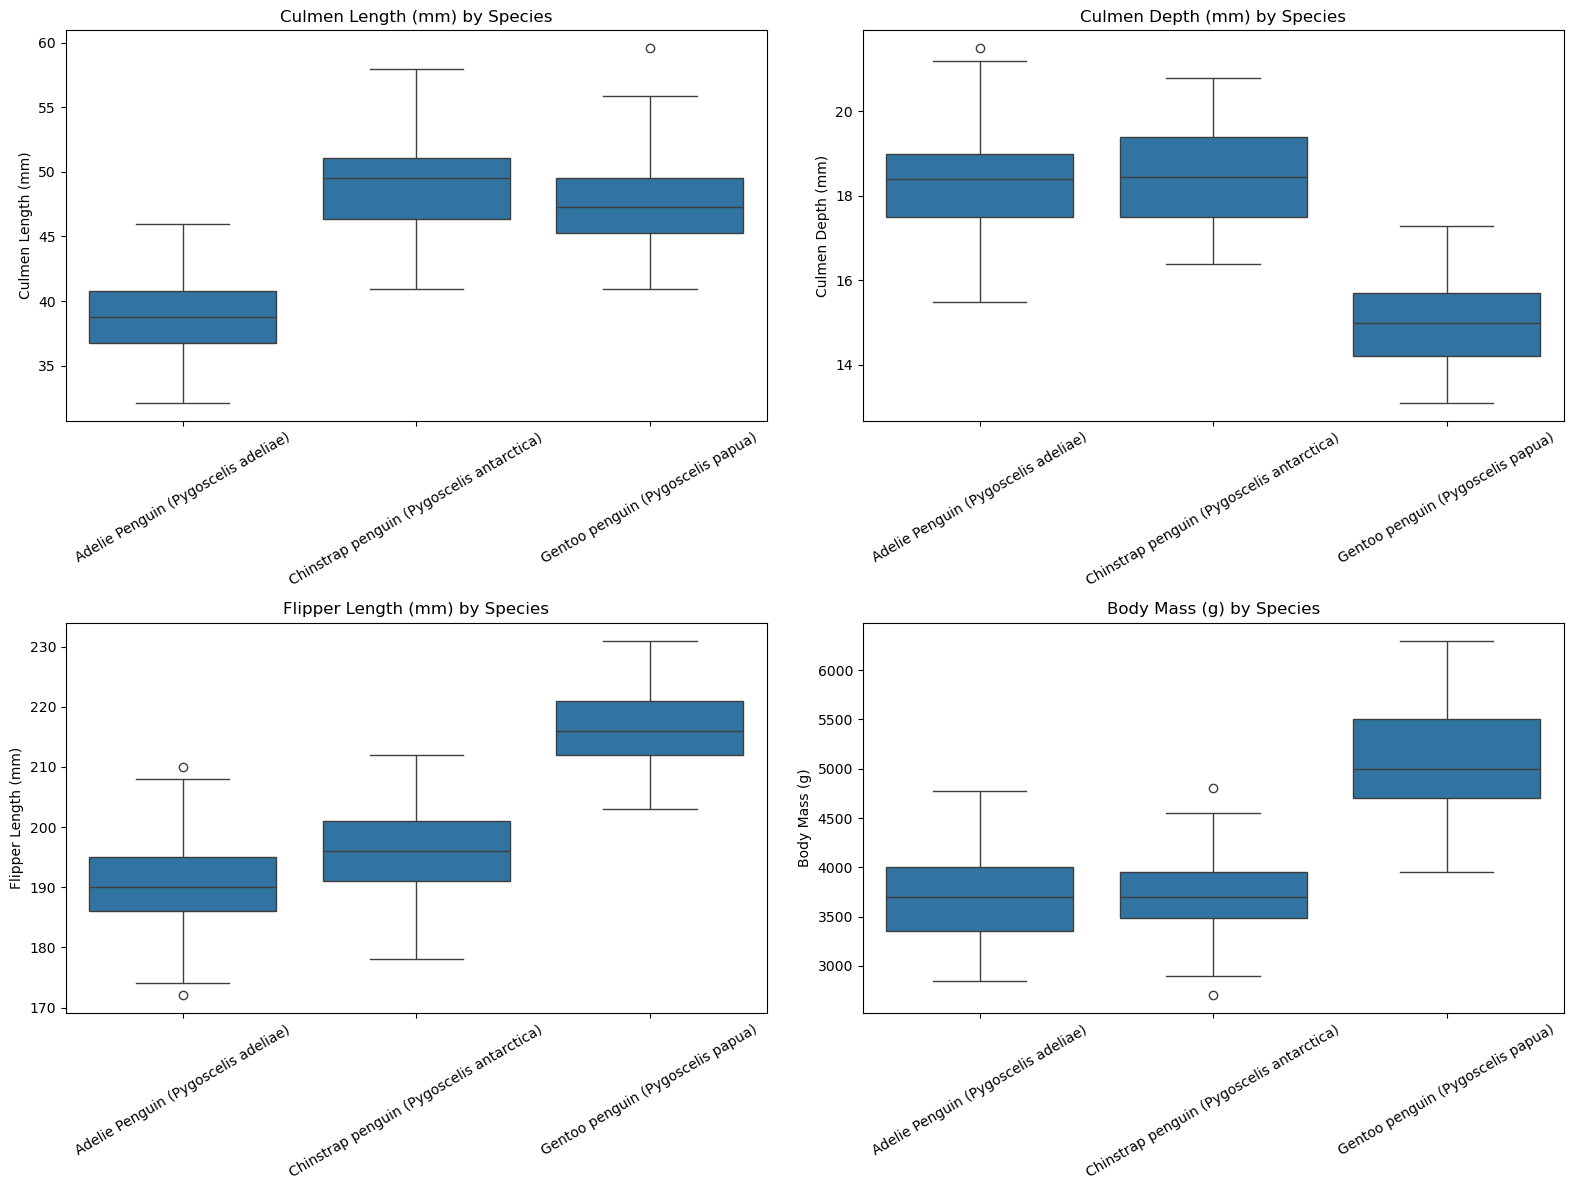

In [25]:
# Visualize how physical measurements vary across penguin species

columns = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']
plt.figure(figsize=(16, 12))
i = 1

for col in columns:
    plt.subplot(2, 2, i)
    sns.boxplot(x = 'Species' , y=col, data=penguins)

    plt.xlabel('')
    plt.ylabel(col)
    plt.title(col + ' by Species')
    plt.xticks(rotation=30)
    i += 1
plt.tight_layout()
plt.show()

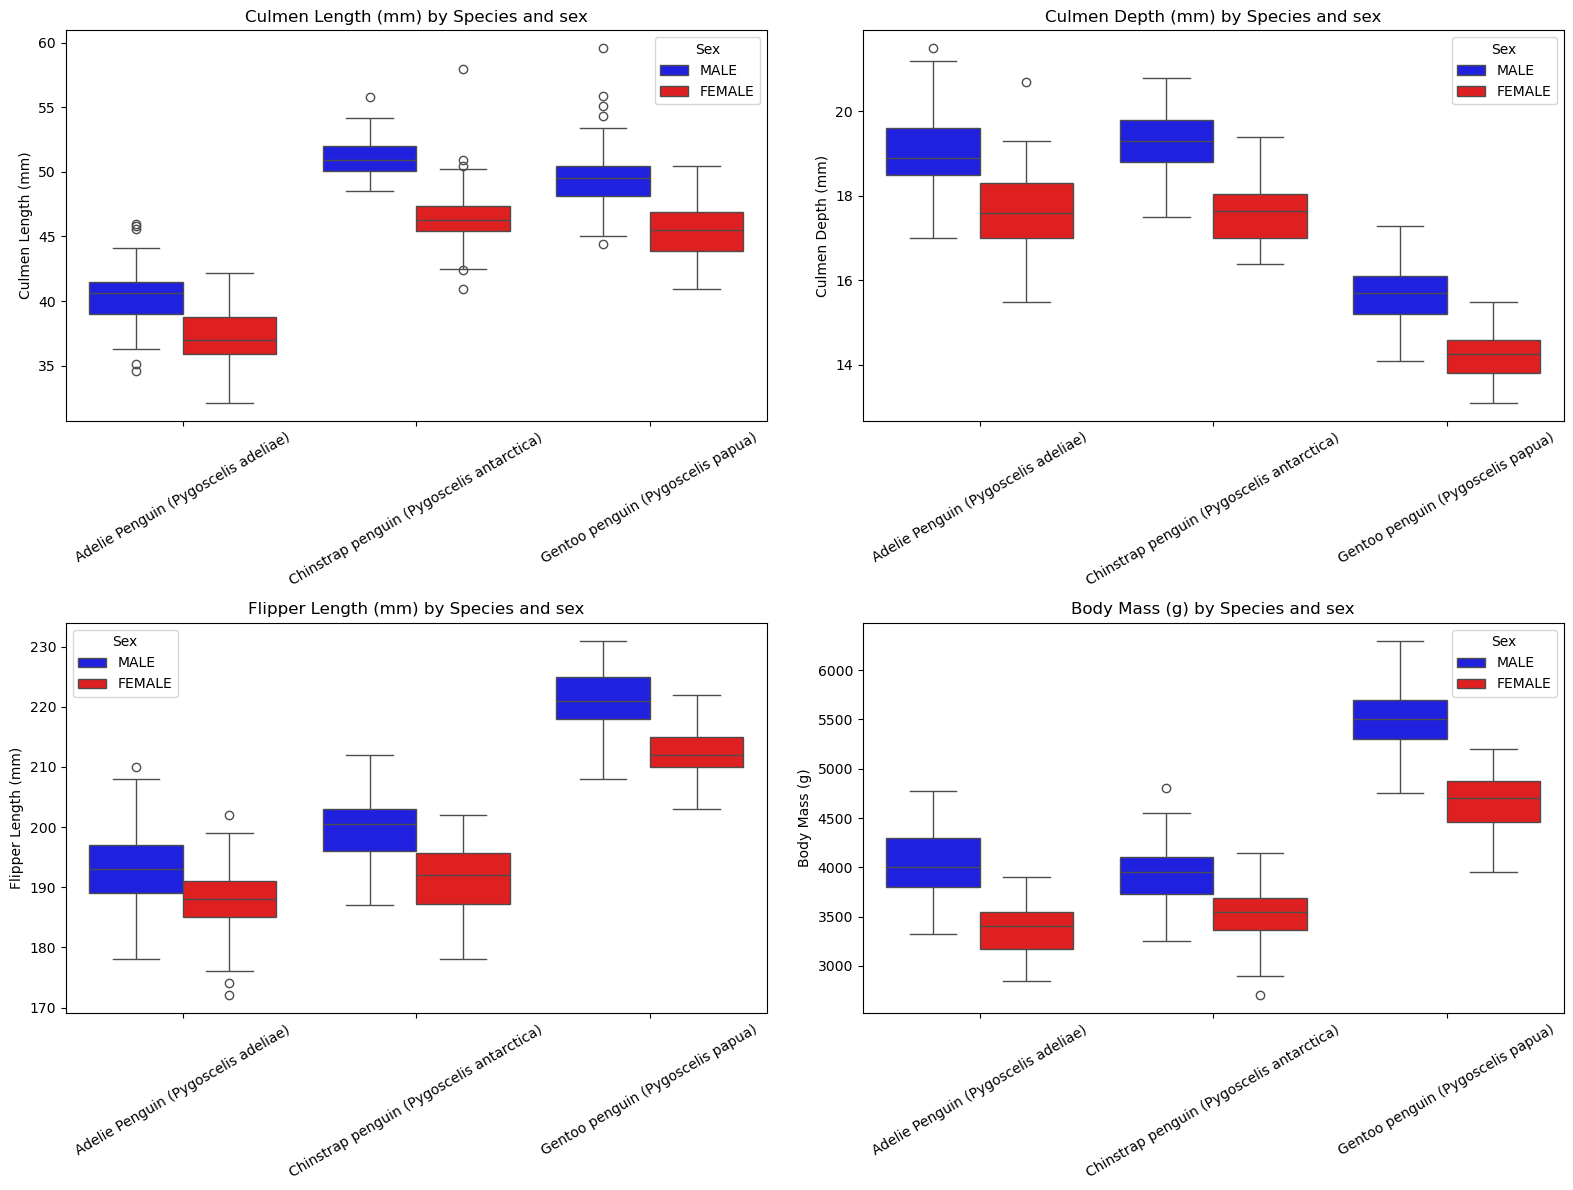

In [26]:
# Visualize how physical measurements vary by species and sex

columns = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'] #while this might not be helpful our goal it can help visualize how species impacts measuremnts
plt.figure(figsize=(16, 12)) #size can be adjusted
i = 1
penguinsfiltered = penguins[(penguins['Sex'] == 'MALE') | (penguins['Sex'] == 'FEMALE')] # just drops all the entry's that have nothing for 'Sex"
for col in columns:
    plt.subplot(2, 2, i)
    sns.boxplot(x = 'Species' , y=col, hue = 'Sex' ,data=penguinsfiltered, palette={'MALE':'blue', 'FEMALE':'red'})

    plt.xlabel('')
    plt.ylabel(col)
    plt.title(col + ' by Species and sex')
    plt.xticks(rotation=30)
    i += 1
plt.tight_layout()
plt.show()

In [27]:
# Calculate summary statistics for each physical measurement by species and sex

columns = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'] #If used in the write up maybe just include Mean and STD
 
penguinsfiltered = penguins[penguins['Sex'].isin(['MALE','FEMALE'])]

tables = {}

for species in penguinsfiltered['Species'].unique():
    species_data = penguinsfiltered[penguinsfiltered['Species'] == species]
    
    male_data = species_data[species_data['Sex'] == 'MALE']
    female_data = species_data[species_data['Sex'] == 'FEMALE']
    
    male_stats = pd.DataFrame({'Mean': male_data[columns].mean(),'Std': male_data[columns].std(),'Median': male_data[columns].median(),'Min': male_data[columns].min(),'Max': male_data[columns].max(),'IQR': male_data[columns].quantile(0.75) - male_data[columns].quantile(0.25)})
    
    female_stats = pd.DataFrame({'Mean': female_data[columns].mean(),'Std': female_data[columns].std(),'Median': female_data[columns].median(),'Min': female_data[columns].min(),'Max': female_data[columns].max(),'IQR': female_data[columns].quantile(0.75) - female_data[columns].quantile(0.25)})
    
    tables[species] = pd.concat([male_stats, female_stats], axis=1, keys=['Male', 'Female'])

summary_table = pd.concat(tables, axis=0)
summary_table

Male  \
                                                                      Mean   
Adelie Penguin (Pygoscelis adeliae)       Culmen Length (mm)     40.390411   
                                          Culmen Depth (mm)      19.072603   
                                          Flipper Length (mm)   192.410959   
                                          Body Mass (g)        4043.493151   
Chinstrap penguin (Pygoscelis antarctica) Culmen Length (mm)     51.094118   
                                          Culmen Depth (mm)      19.252941   
                                          Flipper Length (mm)   199.911765   
                                          Body Mass (g)        3938.970588   
Gentoo penguin (Pygoscelis papua)         Culmen Length (mm)     49.473770   
                                          Culmen Depth (mm)      15.718033   
                                          Flipper Length (mm)   221.540984   
                                          Body Mass (g)        5484.836066   

                                                                           \
                                                                      Std   
Adelie Penguin (Pygoscelis adeliae)       Culmen Length (mm)     2.277131   
                                          Culmen Depth (mm)      1.018886   
                                          Flipper Length (mm)    6.599317   
                                          Body Mass (g)        346.811553   
Chinstrap penguin (Pygoscelis antarctica) Culmen Length (mm)     1.564558   
                                          Culmen Depth (mm)      0.761273   
                                          Flipper Length (mm)    5.976558   
                                          Body Mass (g)        362.137550   
Gentoo penguin (Pygoscelis papua)         Culmen Length (mm)     2.720594   
                                          Culmen Depth (mm)      0.741060   
                                          Flipper Length (mm)    5.673252   
                                          Body Mass (g)        313.158596   

                                                                        \
                                                                Median   
Adelie Penguin (Pygoscelis adeliae)       Culmen Length (mm)     40.60   
                                          Culmen Depth (mm)      18.90   
                                          Flipper Length (mm)   193.00   
                                          Body Mass (g)        4000.00   
Chinstrap penguin (Pygoscelis antarctica) Culmen Length (mm)     50.95   
                                          Culmen Depth (mm)      19.30   
                                          Flipper Length (mm)   200.50   
                                          Body Mass (g)        3950.00   
Gentoo penguin (Pygoscelis papua)         Culmen Length (mm)     49.50   
                                          Culmen Depth (mm)      15.70   
                                          Flipper Length (mm)   221.00   
                                          Body Mass (g)        5500.00   

                                                                               \
                                                                  Min     Max   
Adelie Penguin (Pygoscelis adeliae)       Culmen Length (mm)     34.6    46.0   
                                          Culmen Depth (mm)      17.0    21.5   
                                          Flipper Length (mm)   178.0   210.0   
                                          Body Mass (g)        3325.0  4775.0   
Chinstrap penguin (Pygoscelis antarctica) Culmen Length (mm)     48.5    55.8   
                                          Culmen Depth (mm)      17.5    20.8   
                                          Flipper Length (mm)   187.0   212.0   
                                          Body Mass (g)        3250.0  4800.0   
Gentoo penguin (Pygoscelis papua)         Culmen Le